# Notebook 1 — Data Preprocessing, EDA & Feature Engineering

## Objective
Prepare `dataset.csv` for downstream insurance-claim analysis by validating the schema, cleaning and standardizing fields, parsing vehicle specifications, profiling missingness and duplicates, performing required EDA, engineering business-relevant features, and producing a numerically de-duplicated feature set with VIF diagnostics.

## Methodology
1. Resolve the dataset path robustly and validate required columns.
2. Profile schema, missing values, duplicates, and target imbalance.
3. Remove exact duplicate rows.
4. Detect binary Yes/No columns programmatically and standardize them.
5. Parse leading numeric values from `max_power` and `max_torque`.
6. Correct numeric-looking columns and handle coercion-induced missing values.
7. Apply IQR capping to numeric predictors while excluding the target and flag-like columns.
8. Encode binary flags as 0/1 and one-hot encode the specified nominal variables.
9. Perform univariate, bivariate, and correlation-based EDA.
10. Engineer `High_Risk_Driver_Flag`, `safety_equipment_count`, and `power_to_weight_ratio`.
11. Identify highly correlated numeric feature pairs before VIF.
12. Calculate VIF and assemble `final_modeling_features`.

## Leakage prevention
This notebook is primarily a preprocessing/EDA deliverable rather than a predictive model. Exploratory summaries are explicitly labeled as descriptive. For any subsequent supervised modeling, all training-dependent operations such as imputation, IQR-cap thresholds, and the bottom-quartile threshold must be fitted on the training split and then applied unchanged to validation/test data. The notebook therefore also exposes the fitted thresholds used for the current preprocessing run so they can be transferred to a later modeling pipeline without recomputation on held-out data.

Target `is_claim` is never used to construct cleaning thresholds, feature encodings, or VIF calculations. Correlation with `is_claim` is used only for EDA ranking.


In [34]:
# CELL — Environment and Imports
# Purpose: Import all required libraries in the first code cell and configure reproducible plotting behavior.

from pathlib import Path
import re
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display
from statsmodels.stats.outliers_influence import variance_inflation_factor

warnings.filterwarnings("ignore")

RANDOM_STATE = 42
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 140)
sns.set_theme(style="whitegrid")

REQUIRED_COLUMNS = [
    "policy_id", "policy_tenure", "age_of_car", "age_of_policyholder",
    "area_cluster", "population_density", "make", "segment", "model",
    "fuel_type", "max_torque", "max_power", "engine_type", "airbags",
    "is_esc", "is_adjustable_steering", "is_tpms", "is_parking_sensors",
    "is_parking_camera", "rear_brakes_type", "displacement", "cylinder",
    "transmission_type", "gear_box", "steering_type", "turning_radius",
    "length", "width", "height", "gross_weight", "is_front_fog_lights",
    "is_rear_window_wiper", "is_rear_window_washer",
    "is_rear_window_defogger", "is_brake_assist", "is_power_door_locks",
    "is_central_locking", "is_power_steering",
    "is_driver_seat_height_adjustable", "is_day_night_rear_view_mirror",
    "is_ecw", "is_speed_alert", "ncap_rating", "is_claim",
]

ONE_HOT_COLUMNS = [
    "area_cluster", "segment", "fuel_type", "engine_type",
    "rear_brakes_type", "transmission_type", "steering_type",
]

KEY_NUMERIC_FEATURES = [
    "age_of_policyholder", "age_of_car", "population_density",
    "policy_tenure", "max_power_bhp", "displacement",
    "ncap_rating", "gross_weight",
]

KEY_CATEGORICAL_FEATURES = [
    "area_cluster", "segment", "fuel_type",
    "transmission_type", "is_speed_alert",
]

TARGET_COLUMN = "is_claim"
FLAG_PREFIX = "is_"


In [35]:
# CELL — Robust Dataset Path Resolution
# Purpose: Search common notebook/upload/archive locations before falling back to the current working directory, then validate the selected CSV.

def resolve_dataset_path(filename="dataset.csv"):
    candidate_dirs = [
        Path.cwd(),
        Path("/mnt/user-data/uploads"),
        Path("/mnt/user-data/uploads/archive"),
        Path("/mnt/data"),
        Path("/mnt/data/archive"),
    ]

    checked = []
    for directory in candidate_dirs:
        candidate = directory / filename
        checked.append(str(candidate))
        if candidate.is_file():
            return candidate

    # Recursive fallback is intentionally limited to likely upload/archive roots.
    for root in [Path.cwd(), Path("/mnt/user-data/uploads"), Path("/mnt/data")]:
        if root.exists():
            matches = list(root.rglob(filename))
            if matches:
                return matches[0]

    raise FileNotFoundError(
        "Could not locate dataset.csv. Checked:\n" + "\n".join(checked)
    )


DATA_PATH = resolve_dataset_path()
df = pd.read_csv(DATA_PATH)

missing_required = sorted(set(REQUIRED_COLUMNS) - set(df.columns))
if missing_required:
    raise ValueError(f"Missing required columns: {missing_required}")

print(f"Dataset path: {DATA_PATH}")
print(f"Dataset shape: {df.shape}")
display(df.head())


Dataset path: c:\Users\diwak\Downloads\capstone project-20260811T175611Z-1-001\capstone project\dataset.csv
Dataset shape: (58592, 44)


,policy_id,policy_tenure,age_of_car,age_of_policyholder,area_cluster,population_density,make,segment,model,fuel_type,max_torque,max_power,engine_type,airbags,is_esc,is_adjustable_steering,is_tpms,is_parking_sensors,is_parking_camera,rear_brakes_type,displacement,cylinder,transmission_type,gear_box,steering_type,turning_radius,length,width,height,gross_weight,is_front_fog_lights,is_rear_window_wiper,is_rear_window_washer,is_rear_window_defogger,is_brake_assist,is_power_door_locks,is_central_locking,is_power_steering,is_driver_seat_height_adjustable,is_day_night_rear_view_mirror,is_ecw,is_speed_alert,ncap_rating,is_claim
0,ID00001,0.515874,0.05,0.644231,C1,4990,1,A,M1,CNG,60Nm@3500rpm,40.36bhp@6000rpm,F8D Petrol Engine,2,No,No,No,Yes,No,Drum,796,3,Manual,5,Power,4.6,3445,1515,1475,1185,No,No,No,No,No,No,No,Yes,No,No,No,Yes,0,0
1,ID00002,0.672619,0.02,0.375000,C2,27003,1,A,M1,CNG,60Nm@3500rpm,40.36bhp@6000rpm,F8D Petrol Engine,2,No,No,No,Yes,No,Drum,796,3,Manual,5,Power,4.6,3445,1515,1475,1185,No,No,No,No,No,No,No,Yes,No,No,No,Yes,0,0
2,ID00003,0.841110,0.02,0.384615,C3,4076,1,A,M1,CNG,60Nm@3500rpm,40.36bhp@6000rpm,F8D Petrol Engine,2,No,No,No,Yes,No,Drum,796,3,Manual,5,Power,4.6,3445,1515,1475,1185,No,No,No,No,No,No,No,Yes,No,No,No,Yes,0,0
3,ID00004,0.900277,0.11,0.432692,C4,21622,1,C1,M2,Petrol,113Nm@4400rpm,88.50bhp@6000rpm,1.2 L K12N Dualjet,2,Yes,Yes,No,Yes,Yes,Drum,1197,4,Automatic,5,Electric,4.8,3995,1735,1515,1335,Yes,No,No,Yes,Yes,Yes,Yes,Yes,Yes,Yes,Yes,Yes,2,0
4,ID00005,0.596403,0.11,0.634615,C5,34738,2,A,M3,Petrol,91Nm@4250rpm,67.06bhp@5500rpm,1.0 SCe,2,No,No,No,No,Yes,Drum,999,3,Automatic,5,Electric,5.0,3731,1579,1490,1155,No,No,No,No,No,Yes,Yes,Yes,No,Yes,Yes,Yes,2,0


In [36]:
# CELL — Schema, Missingness, Duplicates and Target Balance
# Purpose: Print the required schema and data-quality diagnostics, including duplicate policy IDs and target imbalance.

print("Dtype counts:")
display(df.dtypes.value_counts().rename("count").to_frame())

print("\nMissing values by column:")
display(df.isna().sum().sort_values(ascending=False).rename("missing_count").to_frame())

exact_duplicate_count = int(df.duplicated().sum())
duplicate_policy_id_count = int(df["policy_id"].duplicated(keep=False).sum())
unique_duplicate_policy_ids = int(df.loc[df["policy_id"].duplicated(keep=False), "policy_id"].nunique())

print(f"Exact duplicate rows: {exact_duplicate_count}")
print(f"Rows belonging to duplicated policy_id values: {duplicate_policy_id_count}")
print(f"Number of duplicated policy_id values: {unique_duplicate_policy_ids}")

target_counts = df[TARGET_COLUMN].value_counts(dropna=False).sort_index()
target_share = df[TARGET_COLUMN].value_counts(normalize=True, dropna=False).sort_index()
print("\nis_claim value counts:")
display(
    pd.DataFrame({"count": target_counts, "proportion": target_share})
)

if len(target_counts) == 2:
    majority = target_counts.max()
    minority = target_counts.min()
    imbalance_ratio = majority / minority if minority else np.inf
    print(f"Class imbalance ratio (majority/minority): {imbalance_ratio:.2f}")


Dtype counts:


,count
object,28
int64,12
float64,4



Missing values by column:


,missing_count
policy_id,0
policy_tenure,0
age_of_car,0
age_of_policyholder,0
area_cluster,0
population_density,0
make,0
segment,0
model,0
fuel_type,0


Exact duplicate rows: 0
Rows belonging to duplicated policy_id values: 0
Number of duplicated policy_id values: 0

is_claim value counts:


,count,proportion
is_claim,,
0,54844,0.936032
1,3748,0.063968


Class imbalance ratio (majority/minority): 14.63


In [37]:
# CELL — Remove Exact Duplicate Rows
# Purpose: Remove exact duplicate records while retaining the first occurrence and verify the resulting row count.

before_rows = len(df)
df_clean = df.drop_duplicates(keep="first").copy()
removed_rows = before_rows - len(df_clean)

print(f"Rows before exact-duplicate removal: {before_rows}")
print(f"Exact duplicate rows removed: {removed_rows}")
print(f"Rows after exact-duplicate removal: {len(df_clean)}")


Rows before exact-duplicate removal: 58592
Exact duplicate rows removed: 0
Rows after exact-duplicate removal: 58592


In [38]:
# CELL — Display Data After Duplicate Removal
# Purpose: Make the cleaned dataframe visibly auditable.

print(f"Current dataframe shape: {df.shape}")
display(df.head(10))


Current dataframe shape: (58592, 44)


,policy_id,policy_tenure,age_of_car,age_of_policyholder,area_cluster,population_density,make,segment,model,fuel_type,max_torque,max_power,engine_type,airbags,is_esc,is_adjustable_steering,is_tpms,is_parking_sensors,is_parking_camera,rear_brakes_type,displacement,cylinder,transmission_type,gear_box,steering_type,turning_radius,length,width,height,gross_weight,is_front_fog_lights,is_rear_window_wiper,is_rear_window_washer,is_rear_window_defogger,is_brake_assist,is_power_door_locks,is_central_locking,is_power_steering,is_driver_seat_height_adjustable,is_day_night_rear_view_mirror,is_ecw,is_speed_alert,ncap_rating,is_claim
0,ID00001,0.515874,0.05,0.644231,C1,4990,1,A,M1,CNG,60Nm@3500rpm,40.36bhp@6000rpm,F8D Petrol Engine,2,No,No,No,Yes,No,Drum,796,3,Manual,5,Power,4.60,3445,1515,1475,1185,No,No,No,No,No,No,No,Yes,No,No,No,Yes,0,0
1,ID00002,0.672619,0.02,0.375000,C2,27003,1,A,M1,CNG,60Nm@3500rpm,40.36bhp@6000rpm,F8D Petrol Engine,2,No,No,No,Yes,No,Drum,796,3,Manual,5,Power,4.60,3445,1515,1475,1185,No,No,No,No,No,No,No,Yes,No,No,No,Yes,0,0
2,ID00003,0.841110,0.02,0.384615,C3,4076,1,A,M1,CNG,60Nm@3500rpm,40.36bhp@6000rpm,F8D Petrol Engine,2,No,No,No,Yes,No,Drum,796,3,Manual,5,Power,4.60,3445,1515,1475,1185,No,No,No,No,No,No,No,Yes,No,No,No,Yes,0,0
3,ID00004,0.900277,0.11,0.432692,C4,21622,1,C1,M2,Petrol,113Nm@4400rpm,88.50bhp@6000rpm,1.2 L K12N Dualjet,2,Yes,Yes,No,Yes,Yes,Drum,1197,4,Automatic,5,Electric,4.80,3995,1735,1515,1335,Yes,No,No,Yes,Yes,Yes,Yes,Yes,Yes,Yes,Yes,Yes,2,0
4,ID00005,0.596403,0.11,0.634615,C5,34738,2,A,M3,Petrol,91Nm@4250rpm,67.06bhp@5500rpm,1.0 SCe,2,No,No,No,No,Yes,Drum,999,3,Automatic,5,Electric,5.00,3731,1579,1490,1155,No,No,No,No,No,Yes,Yes,Yes,No,Yes,Yes,Yes,2,0
5,ID00006,1.018709,0.07,0.519231,C6,13051,3,C2,M4,Diesel,250Nm@2750rpm,113.45bhp@4000rpm,1.5 L U2 CRDi,6,Yes,Yes,Yes,Yes,Yes,Disc,1493,4,Automatic,6,Power,5.20,4300,1790,1635,1720,Yes,Yes,Yes,Yes,Yes,Yes,Yes,Yes,Yes,No,Yes,Yes,3,0
6,ID00007,0.097992,0.16,0.403846,C7,6112,4,B2,M5,Diesel,200Nm@3000rpm,88.77bhp@4000rpm,1.5 Turbocharged Revotorq,2,No,Yes,No,Yes,No,Drum,1497,4,Manual,5,Electric,5.00,3990,1755,1523,1490,No,No,No,No,No,Yes,Yes,Yes,No,No,Yes,Yes,5,0
7,ID00008,0.509085,0.14,0.423077,C8,8794,1,B2,M6,Petrol,113Nm@4400rpm,88.50bhp@6000rpm,K Series Dual jet,2,No,Yes,No,Yes,No,Drum,1197,4,Manual,5,Electric,4.80,3845,1735,1530,1335,Yes,No,No,No,Yes,Yes,Yes,Yes,Yes,Yes,Yes,Yes,2,0
8,ID00009,0.282394,0.07,0.298077,C7,6112,3,C2,M4,Diesel,250Nm@2750rpm,113.45bhp@4000rpm,1.5 L U2 CRDi,6,Yes,Yes,Yes,Yes,Yes,Disc,1493,4,Automatic,6,Power,5.20,4300,1790,1635,1720,Yes,Yes,Yes,Yes,Yes,Yes,Yes,Yes,Yes,No,Yes,Yes,3,0
9,ID00010,0.566255,0.04,0.442308,C9,17804,1,B2,M7,Petrol,113Nm@4400rpm,88.50bhp@6000rpm,1.2 L K Series Engine,6,Yes,Yes,No,Yes,Yes,Drum,1197,4,Automatic,5,Electric,4.85,3990,1745,1500,1410,Yes,Yes,Yes,Yes,Yes,Yes,Yes,Yes,Yes,Yes,Yes,Yes,0,0


In [39]:
# CELL — Programmatic Yes/No Detection and Standardization
# Purpose: Detect object columns containing only Yes/No values (ignoring missing values), normalize whitespace/case, and verify binary flags.

def detect_yes_no_columns(dataframe):
    yes_no_columns = []
    for column in dataframe.select_dtypes(include="object").columns:
        normalized = dataframe[column].dropna().astype(str).str.strip().str.title()
        if len(normalized) > 0 and normalized.isin({"Yes", "No"}).all():
            yes_no_columns.append(column)
    return yes_no_columns


yes_no_columns = detect_yes_no_columns(df_clean)

for column in yes_no_columns:
    df_clean[column] = df_clean[column].astype("string").str.strip().str.title()

print("Detected Yes/No columns:")
print(yes_no_columns)

non_standard_values = {}
for column in yes_no_columns:
    values = set(df_clean[column].dropna().astype(str).unique())
    invalid = values - {"Yes", "No"}
    if invalid:
        non_standard_values[column] = sorted(invalid)

if non_standard_values:
    raise ValueError(f"Non-standard binary values remain: {non_standard_values}")

print("\nAll detected binary flag columns are standardized to 'Yes'/'No'.")


Detected Yes/No columns:
['is_esc', 'is_adjustable_steering', 'is_tpms', 'is_parking_sensors', 'is_parking_camera', 'is_front_fog_lights', 'is_rear_window_wiper', 'is_rear_window_washer', 'is_rear_window_defogger', 'is_brake_assist', 'is_power_door_locks', 'is_central_locking', 'is_power_steering', 'is_driver_seat_height_adjustable', 'is_day_night_rear_view_mirror', 'is_ecw', 'is_speed_alert']

All detected binary flag columns are standardized to 'Yes'/'No'.


In [40]:
# CELL — Parse max_power and max_torque
# Purpose: Extract the first numeric token from vehicle specification strings and create numeric BHP/Nm columns.

def extract_leading_number(value):
    if pd.isna(value):
        return np.nan
    match = re.search(r"[-+]?\d+(?:\.\d+)?", str(value).strip())
    return float(match.group()) if match else np.nan


df_clean["max_power_bhp"] = df_clean["max_power"].apply(extract_leading_number)
df_clean["max_torque_nm"] = df_clean["max_torque"].apply(extract_leading_number)

display(
    df_clean[["max_power", "max_power_bhp", "max_torque", "max_torque_nm"]].head(10)
)

print("Parsed missing values:")
print(
    df_clean[["max_power_bhp", "max_torque_nm"]]
    .isna()
    .sum()
)


,max_power,max_power_bhp,max_torque,max_torque_nm
0,40.36bhp@6000rpm,40.36,60Nm@3500rpm,60.0
1,40.36bhp@6000rpm,40.36,60Nm@3500rpm,60.0
2,40.36bhp@6000rpm,40.36,60Nm@3500rpm,60.0
3,88.50bhp@6000rpm,88.50,113Nm@4400rpm,113.0
4,67.06bhp@5500rpm,67.06,91Nm@4250rpm,91.0
5,113.45bhp@4000rpm,113.45,250Nm@2750rpm,250.0
6,88.77bhp@4000rpm,88.77,200Nm@3000rpm,200.0
7,88.50bhp@6000rpm,88.50,113Nm@4400rpm,113.0
8,113.45bhp@4000rpm,113.45,250Nm@2750rpm,250.0
9,88.50bhp@6000rpm,88.50,113Nm@4400rpm,113.0


Parsed missing values:
max_power_bhp    0
max_torque_nm    0
dtype: int64


In [41]:
# CELL — Datatype Correction
# Purpose: Convert known numeric-looking columns to numeric types using pandas coercion and report any values that become missing.

numeric_candidates = [
    "policy_tenure", "age_of_car", "age_of_policyholder",
    "population_density", "make", "airbags", "displacement",
    "cylinder", "gear_box", "turning_radius", "length", "width",
    "height", "gross_weight", "ncap_rating", "is_claim",
    "max_power_bhp", "max_torque_nm",
]

coercion_report = []

for column in numeric_candidates:
    if column in df_clean.columns:
        before_missing = df_clean[column].isna().sum()
        df_clean[column] = pd.to_numeric(df_clean[column], errors="coerce")
        after_missing = df_clean[column].isna().sum()
        coercion_report.append(
            {
                "column": column,
                "missing_before": before_missing,
                "missing_after": after_missing,
                "new_missing_from_coercion": after_missing - before_missing,
            }
        )

display(pd.DataFrame(coercion_report))

print("Updated numeric dtypes:")
display(df_clean[numeric_candidates].dtypes.rename("dtype").to_frame())


,column,missing_before,missing_after,new_missing_from_coercion
0,policy_tenure,0,0,0
1,age_of_car,0,0,0
2,age_of_policyholder,0,0,0
3,population_density,0,0,0
4,make,0,0,0
5,airbags,0,0,0
6,displacement,0,0,0
7,cylinder,0,0,0
8,gear_box,0,0,0
9,turning_radius,0,0,0


Updated numeric dtypes:


,dtype
policy_tenure,float64
age_of_car,float64
age_of_policyholder,float64
population_density,int64
make,int64
airbags,int64
displacement,int64
cylinder,int64
gear_box,int64
turning_radius,float64


In [42]:
# CELL — Missing-Value Handling
# Purpose: Impute numeric columns with medians and categorical columns with modes, while recording the fitted values for reproducibility.

imputation_values = {"numeric": {}, "categorical": {}}

numeric_columns = df_clean.select_dtypes(include=np.number).columns.tolist()
categorical_columns = df_clean.select_dtypes(include=["object", "string", "category"]).columns.tolist()

for column in numeric_columns:
    if df_clean[column].isna().any():
        median_value = df_clean[column].median()
        if pd.isna(median_value):
            raise ValueError(f"Cannot impute numeric column '{column}' because its median is NaN.")
        imputation_values["numeric"][column] = float(median_value)
        df_clean[column] = df_clean[column].fillna(median_value)

for column in categorical_columns:
    if df_clean[column].isna().any():
        mode_values = df_clean[column].mode(dropna=True)
        if mode_values.empty:
            raise ValueError(f"Cannot impute categorical column '{column}' because no mode exists.")
        mode_value = mode_values.iloc[0]
        imputation_values["categorical"][column] = str(mode_value)
        df_clean[column] = df_clean[column].fillna(mode_value)

remaining_missing = int(df_clean.isna().sum().sum())
print(f"Total missing values after imputation: {remaining_missing}")

if remaining_missing:
    display(df_clean.isna().sum().loc[lambda s: s > 0])
else:
    print("No missing values remain.")


Total missing values after imputation: 0
No missing values remain.


In [43]:
# CELL — IQR-Based Outlier Capping
# Purpose: Cap numeric predictors using the 1.5×IQR rule while excluding the target and binary flag-like columns.

def is_flag_like_column(series, column_name):
    if column_name == TARGET_COLUMN:
        return True
    if column_name.startswith(FLAG_PREFIX):
        return True

    non_missing = series.dropna()
    if non_missing.empty:
        return False

    unique_values = set(non_missing.unique())
    return unique_values.issubset({0, 1})


outlier_caps = {}
numeric_columns = df_clean.select_dtypes(include=np.number).columns.tolist()

for column in numeric_columns:
    if is_flag_like_column(df_clean[column], column):
        continue

    q1 = df_clean[column].quantile(0.25)
    q3 = df_clean[column].quantile(0.75)
    iqr = q3 - q1

    if pd.isna(iqr) or iqr == 0:
        continue

    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    outlier_caps[column] = {"lower": float(lower), "upper": float(upper)}

    df_clean[column] = df_clean[column].clip(lower=lower, upper=upper)

print(f"Numeric columns capped: {len(outlier_caps)}")
display(pd.DataFrame(outlier_caps).T.rename(columns={"lower": "lower_cap", "upper": "upper_cap"}).head(20))


Numeric columns capped: 16


,lower_cap,upper_cap
policy_tenure,-1.033032,2.282386
age_of_car,-0.115000,0.245000
age_of_policyholder,0.091346,0.822115
population_density,-25224.500000,58339.500000
make,-2.000000,6.000000
airbags,-4.000000,12.000000
displacement,-249.500000,2538.500000
cylinder,1.500000,5.500000
turning_radius,4.000000,5.600000
length,2620.000000,4820.000000


In [44]:
# CELL — Binary Label Encoding
# Purpose: Map every standardized Yes/No flag to 1/0 and verify that no Yes/No strings remain in the cleaned dataset.

binary_mapping = {"Yes": 1, "No": 0}

for column in yes_no_columns:
    df_clean[column] = df_clean[column].map(binary_mapping).astype("int64")

remaining_yes_no_columns = []
for column in df_clean.select_dtypes(include=["object", "string", "category"]).columns:
    values = set(df_clean[column].dropna().astype(str).str.strip().str.title().unique())
    if values & {"Yes", "No"}:
        remaining_yes_no_columns.append(column)

print("Binary columns encoded:")
print(yes_no_columns)

if remaining_yes_no_columns:
    raise ValueError(f"Yes/No strings remain in: {remaining_yes_no_columns}")

print("Confirmed: no Yes/No strings remain in df_clean.")


Binary columns encoded:
['is_esc', 'is_adjustable_steering', 'is_tpms', 'is_parking_sensors', 'is_parking_camera', 'is_front_fog_lights', 'is_rear_window_wiper', 'is_rear_window_washer', 'is_rear_window_defogger', 'is_brake_assist', 'is_power_door_locks', 'is_central_locking', 'is_power_steering', 'is_driver_seat_height_adjustable', 'is_day_night_rear_view_mirror', 'is_ecw', 'is_speed_alert']
Confirmed: no Yes/No strings remain in df_clean.


In [45]:
# CELL — One-Hot Encode Nominal Variables
# Purpose: One-hot encode the seven required low/medium-cardinality nominal variables without dropping the first level.

missing_one_hot_columns = sorted(set(ONE_HOT_COLUMNS) - set(df_clean.columns))
if missing_one_hot_columns:
    raise ValueError(f"Missing one-hot columns: {missing_one_hot_columns}")

df_clean = pd.get_dummies(
    df_clean,
    columns=ONE_HOT_COLUMNS,
    drop_first=False,
    dtype=int,
)

print(f"Shape after one-hot encoding: {df_clean.shape}")
print("One-hot encoding completed with drop_first=False.")


Shape after one-hot encoding: (58592, 88)
One-hot encoding completed with drop_first=False.


In [46]:
# CELL — Display Encoded Clean Dataset
# Purpose: Display the cleaned/encoded dataframe and schema.

print(f"df_clean shape after encoding: {df_clean.shape}")
display(df_clean.head(10))
display(df_clean.dtypes.value_counts().rename("dtype_count").to_frame())


df_clean shape after encoding: (58592, 88)


,policy_id,policy_tenure,age_of_car,age_of_policyholder,population_density,make,model,max_torque,max_power,airbags,is_esc,is_adjustable_steering,is_tpms,is_parking_sensors,is_parking_camera,displacement,cylinder,gear_box,turning_radius,length,width,height,gross_weight,is_front_fog_lights,is_rear_window_wiper,is_rear_window_washer,is_rear_window_defogger,is_brake_assist,is_power_door_locks,is_central_locking,is_power_steering,is_driver_seat_height_adjustable,is_day_night_rear_view_mirror,is_ecw,is_speed_alert,ncap_rating,is_claim,max_power_bhp,max_torque_nm,area_cluster_C1,area_cluster_C10,area_cluster_C11,area_cluster_C12,area_cluster_C13,area_cluster_C14,area_cluster_C15,area_cluster_C16,area_cluster_C17,area_cluster_C18,area_cluster_C19,area_cluster_C2,area_cluster_C20,area_cluster_C21,area_cluster_C22,area_cluster_C3,area_cluster_C4,area_cluster_C5,area_cluster_C6,area_cluster_C7,area_cluster_C8,area_cluster_C9,segment_A,segment_B1,segment_B2,segment_C1,segment_C2,segment_Utility,fuel_type_CNG,fuel_type_Diesel,fuel_type_Petrol,engine_type_1.0 SCe,engine_type_1.2 L K Series Engine,engine_type_1.2 L K12N Dualjet,engine_type_1.5 L U2 CRDi,engine_type_1.5 Turbocharged Revotorq,engine_type_1.5 Turbocharged Revotron,engine_type_F8D Petrol Engine,engine_type_G12B,engine_type_K Series Dual jet,engine_type_K10C,engine_type_i-DTEC,rear_brakes_type_Disc,rear_brakes_type_Drum,transmission_type_Automatic,transmission_type_Manual,steering_type_Electric,steering_type_Manual,steering_type_Power
0,ID00001,0.515874,0.05,0.644231,4990.0,1,M1,60Nm@3500rpm,40.36bhp@6000rpm,2,0,0,0,1,0,796,3,5,4.60,3445,1515,1475,1185,0,0,0,0,0,0,0,1,0,0,0,1,0,0,40.36,60.0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,1,0,1,0,0,1
1,ID00002,0.672619,0.02,0.375000,27003.0,1,M1,60Nm@3500rpm,40.36bhp@6000rpm,2,0,0,0,1,0,796,3,5,4.60,3445,1515,1475,1185,0,0,0,0,0,0,0,1,0,0,0,1,0,0,40.36,60.0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,1,0,1,0,0,1
2,ID00003,0.841110,0.02,0.384615,4076.0,1,M1,60Nm@3500rpm,40.36bhp@6000rpm,2,0,0,0,1,0,796,3,5,4.60,3445,1515,1475,1185,0,0,0,0,0,0,0,1,0,0,0,1,0,0,40.36,60.0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,1,0,0,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,1,0,1,0,0,1
3,ID00004,0.900277,0.11,0.432692,21622.0,1,M2,113Nm@4400rpm,88.50bhp@6000rpm,2,1,1,0,1,1,1197,4,5,4.80,3995,1735,1515,1335,1,0,0,1,1,1,1,1,1,1,1,1,2,0,88.50,113.0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,1,0,0,1,0,0,0,0,0,0,0,0,0,1,1,0,1,0,0
4,ID00005,0.596403,0.11,0.634615,34738.0,2,M3,91Nm@4250rpm,67.06bhp@5500rpm,2,0,0,0,0,1,999,3,5,5.00,3731,1579,1490,1155,0,0,0,0,0,1,1,1,0,1,1,1,2,0,67.06,91.0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,1,0,0,0,0,0,0,0,1,1,0,0,0,0,0,0,0,0,0,0,0,1,1,0,1,0,0
5,ID00006,1.018709,0.07,0.519231,13051.0,3,M4,250Nm@2750rpm,113.45bhp@4000rpm,6,1,1,1,1,1,1493,4,6,5.20,4300,1790,1635,1720,1,1,1,1,1,1,1,1,1,0,1,1,3,0,113.45,250.0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,1,0,0,1,0,0,0,0,1,0,0,0,0,0,0,0,1,0,1,0,0,0,1
6,ID00007,0.097992,0.16,0.403846,6112.0,4,M5,200Nm@3000rpm,88.77bhp@4000rpm,2,0,1,0,1,0,1497,4,5,5.00,3990,1755,1523,1490,0,0,0,0,0,1,1,1,0,0,1,1,5,0,88.77,200.0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,1,0,0,0,0,1,0,0,0,0,0,1,0,0,0,0,0,0,0,1,0,1,1,0,0
7,ID00008,0.509085,0.14,0.423077,8794.0,1,M6,113Nm@4400rpm,88.50bhp@6000rpm,2,0,1,0,1,0,1197,4,5,4.80,3845,1735,1530,1335,1,0,0,0,1,1,1,1,1,1,1,1,2,0,88.50,113.0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,1,0,0,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,1,0,1,1,0,0
8,ID00009,0.282394,0.07,0.298077,6112.0,3,M4,250Nm@2750rpm,113.45bhp@4000rpm,6,1,1,1,1,1,1493,4,6,5.20,4300,1790,1635,1720,1,1,1,1,1,1,1,1,1,0,1,1,3,0,113.45,250.0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,1,0,0,1,0,0,0,0,1,0,0,0,0,0,0,0,1,0,1,0,0,0,1
9,ID00010,0.566255,0.04,0.442308,17804.0,1,M7,113Nm@4400rpm,88.50bhp@6000rpm,6,1,1,0,1,1,1197,4,5,4.85,3990,1745,1500,1410,1,1,1,1,1,1,1,1,1,1,1,1,0,0,88.50,

,dtype_count
int64,77
float64,7
object,4


# Exploratory Data Analysis

The following EDA cells use the cleaned values for numeric summaries and the original raw dataset for the requested categorical count charts. EDA is descriptive and does not feed target-aware transformations into modeling.


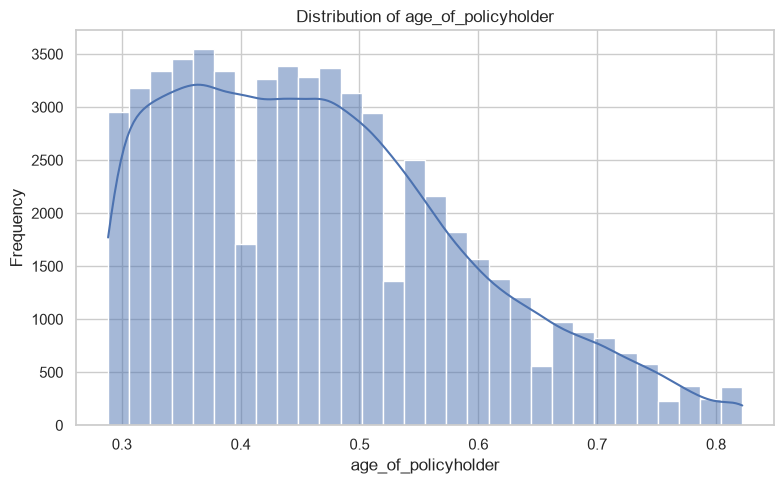

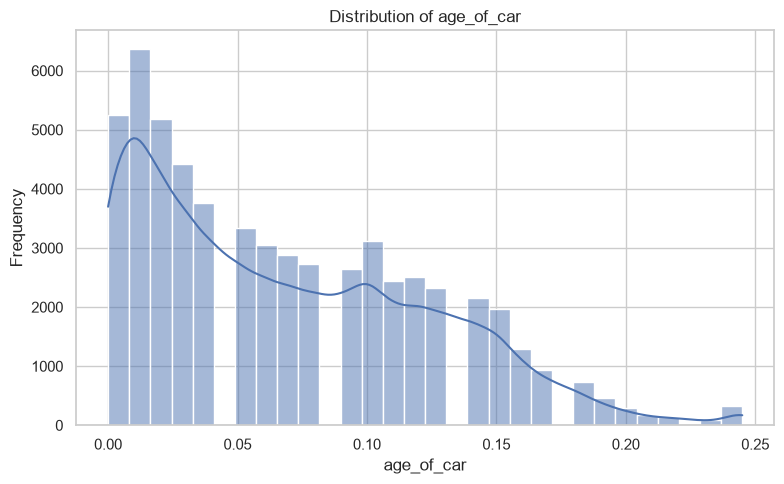

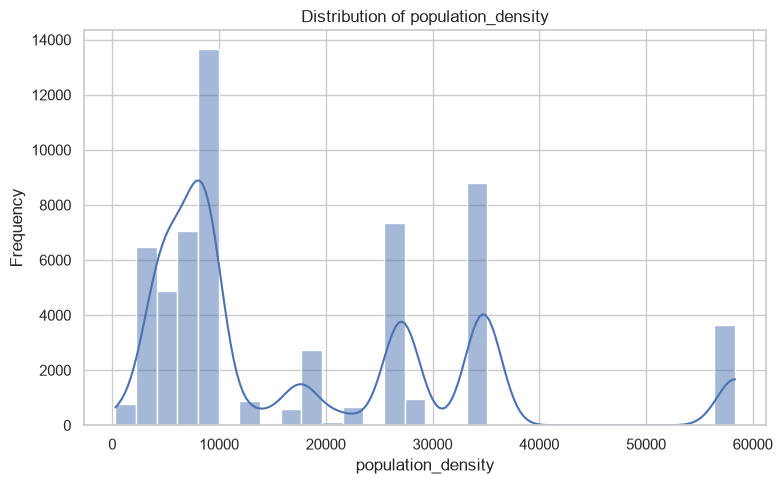

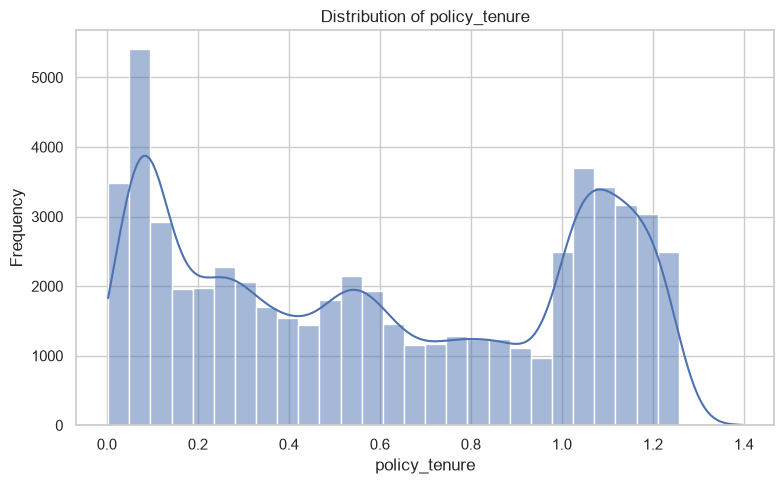

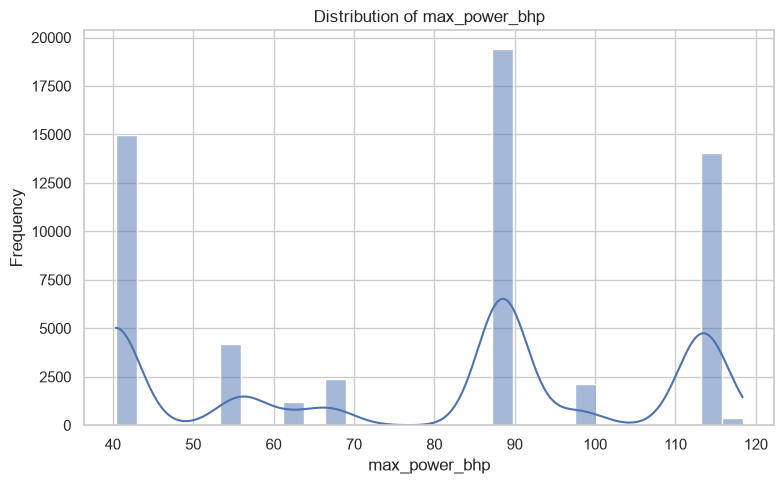

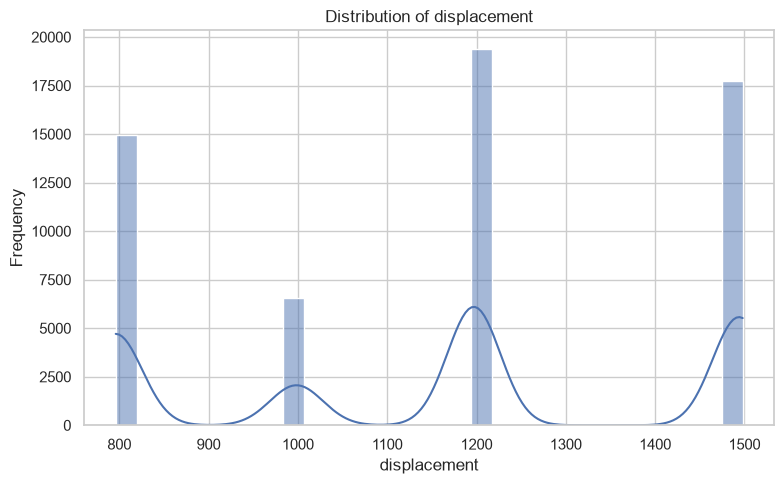

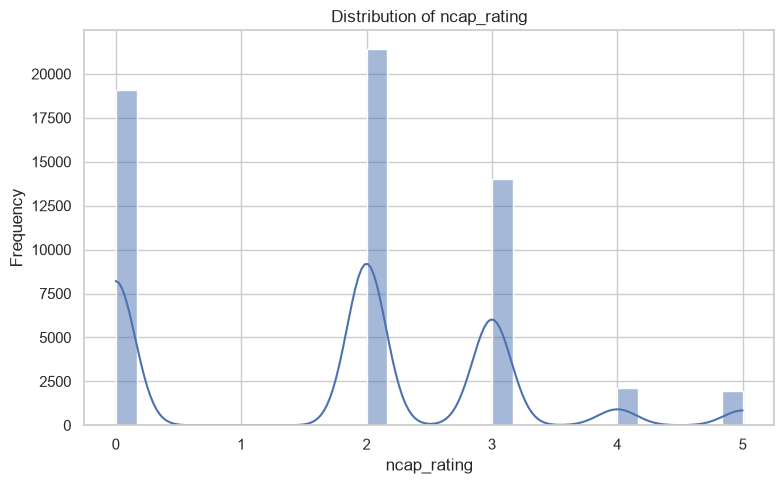

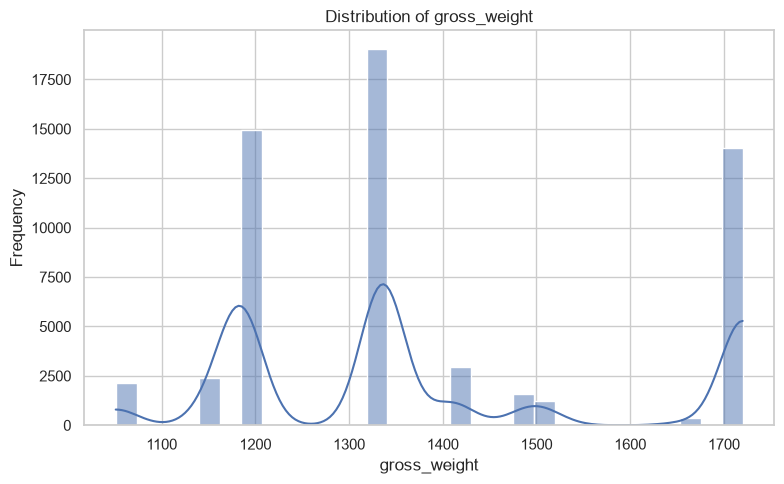

In [47]:
# CELL — Univariate Numeric Distributions
# Purpose: Plot histograms with KDE for all eight required numeric features.

available_numeric = [column for column in KEY_NUMERIC_FEATURES if column in df_clean.columns]

for column in available_numeric:
    plt.figure(figsize=(8, 5))
    sns.histplot(df_clean[column], kde=True, bins=30)
    plt.title(f"Distribution of {column}")
    plt.xlabel(column)
    plt.ylabel("Frequency")
    plt.tight_layout()
    plt.show()


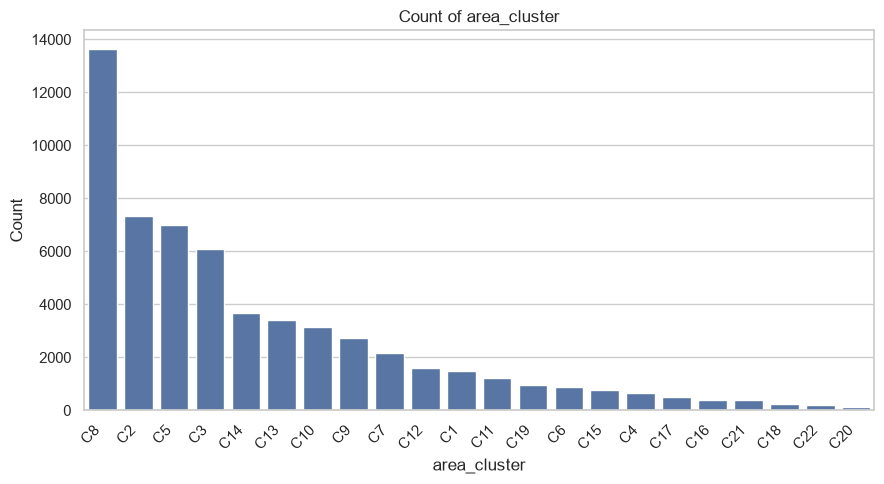

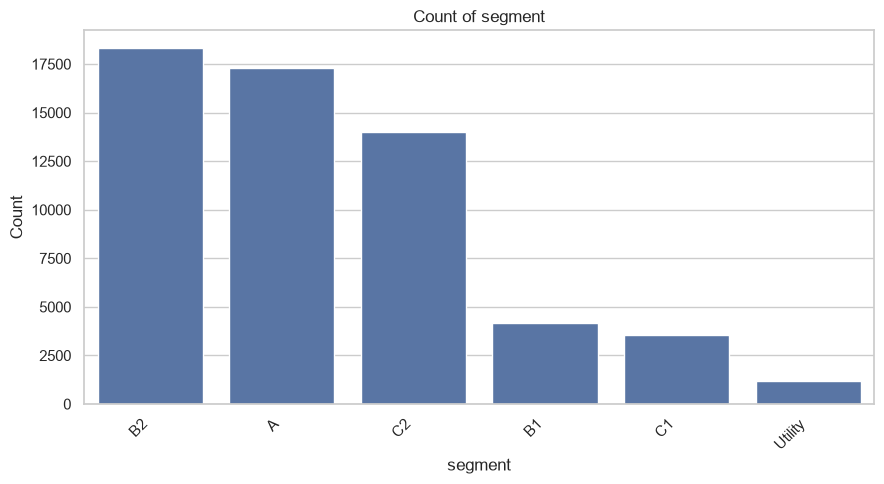

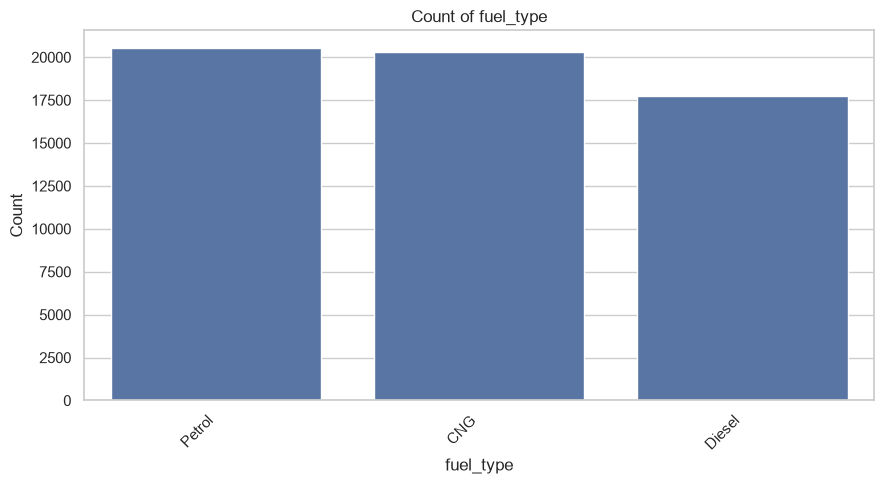

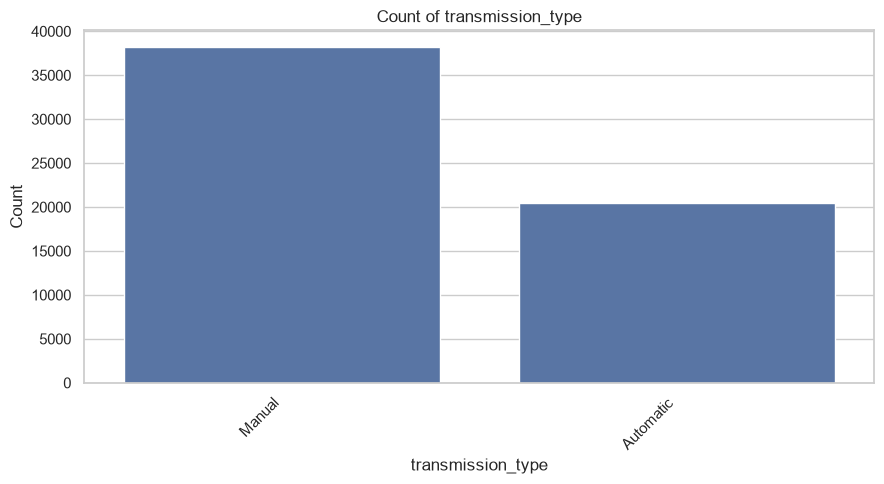

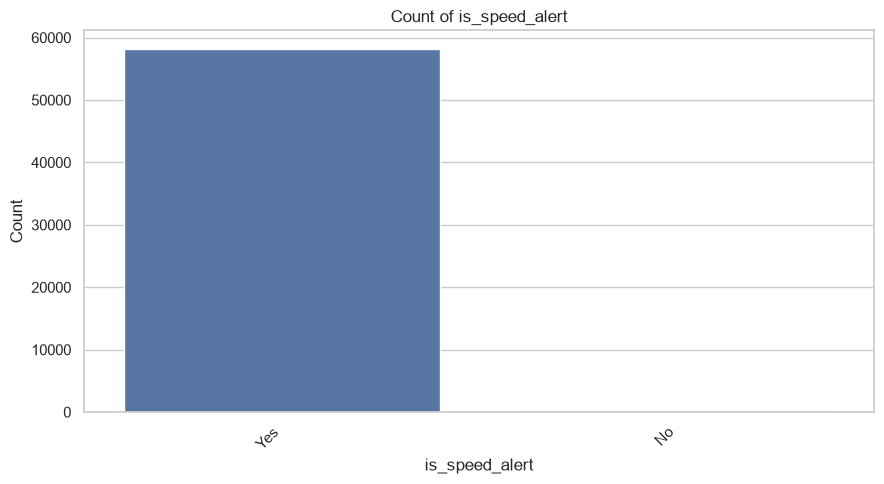

In [48]:
# CELL — Univariate Categorical Count Charts
# Purpose: Plot count charts for key categorical variables from the original raw dataset.

raw_categorical_features = [
    column for column in KEY_CATEGORICAL_FEATURES if column in df.columns
]

for column in raw_categorical_features:
    plt.figure(figsize=(9, 5))
    order = df[column].astype(str).value_counts().index
    sns.countplot(data=df, x=column, order=order)
    plt.title(f"Count of {column}")
    plt.xlabel(column)
    plt.ylabel("Count")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()


,_bin,claim_rate_percent
0,"(0.287, 0.356]",5.590783
1,"(0.356, 0.423]",6.107128
2,"(0.423, 0.49]",6.828764
3,"(0.49, 0.567]",6.514720
4,"(0.567, 0.822]",7.048043


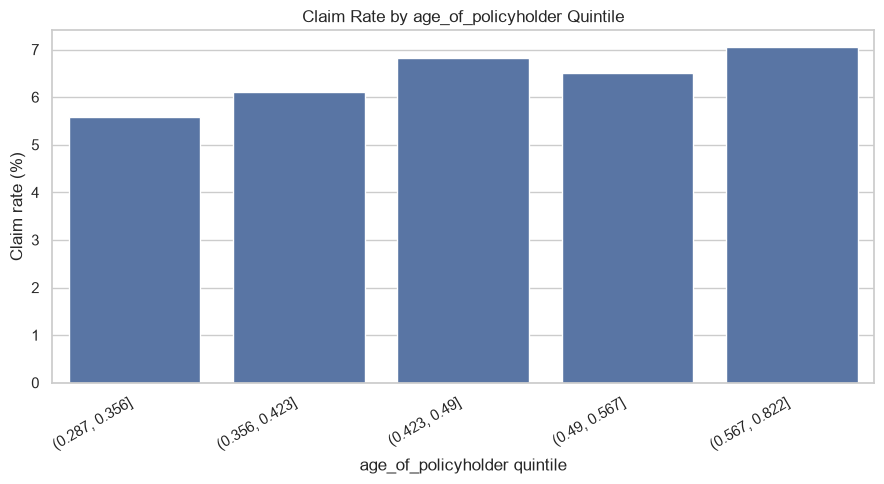

,_bin,claim_rate_percent
0,"(-0.001, 0.02]",6.943122
1,"(0.02, 0.04]",6.358523
2,"(0.04, 0.08]",6.759344
3,"(0.08, 0.12]",6.542841
4,"(0.12, 0.245]",5.037228


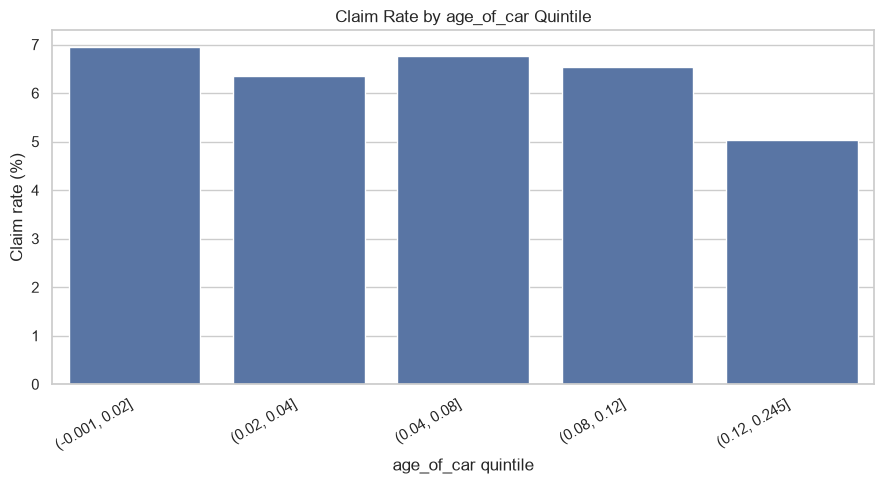

,_bin,claim_rate_percent
0,"(289.999, 5410.0]",6.349860
1,"(5410.0, 8794.0]",6.842894
2,"(8794.0, 17804.0]",5.458412
3,"(17804.0, 34738.0]",6.543279
4,"(34738.0, 58339.5]",5.111355


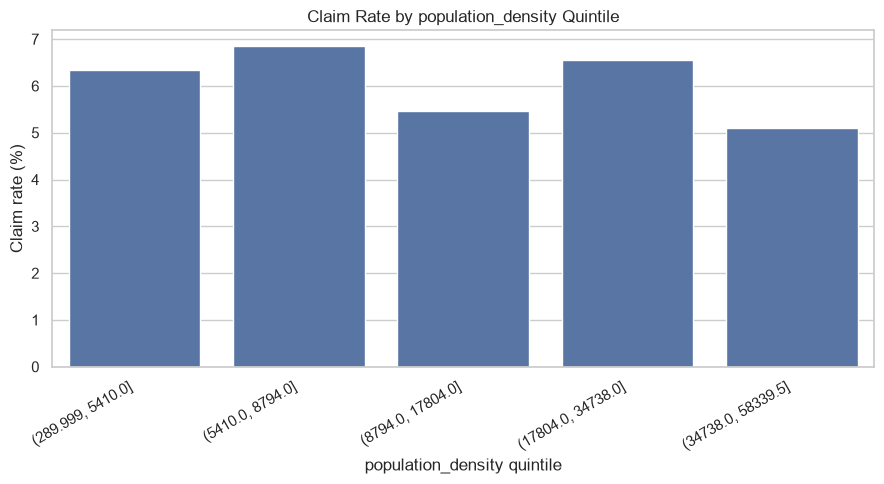

In [49]:
# CELL — Claim Rate by Continuous Predictor Quintiles
# Purpose: Bin the three requested continuous predictors into quintiles using qcut(q=5, duplicates='drop') and plot mean claim rate.

continuous_target_features = [
    "age_of_policyholder",
    "age_of_car",
    "population_density",
]

for column in continuous_target_features:
    binned = pd.qcut(
        df_clean[column],
        q=5,
        duplicates="drop",
    )
    claim_rate = (
        df_clean.assign(_bin=binned)
        .groupby("_bin", observed=True)[TARGET_COLUMN]
        .mean()
        .mul(100)
        .reset_index(name="claim_rate_percent")
    )

    display(claim_rate)

    plt.figure(figsize=(9, 5))
    sns.barplot(data=claim_rate, x="_bin", y="claim_rate_percent")
    plt.title(f"Claim Rate by {column} Quintile")
    plt.xlabel(f"{column} quintile")
    plt.ylabel("Claim rate (%)")
    plt.xticks(rotation=30, ha="right")
    plt.tight_layout()
    plt.show()


,is_speed_alert,claim_rate_percent
1,1,6.410895
0,0,4.132231


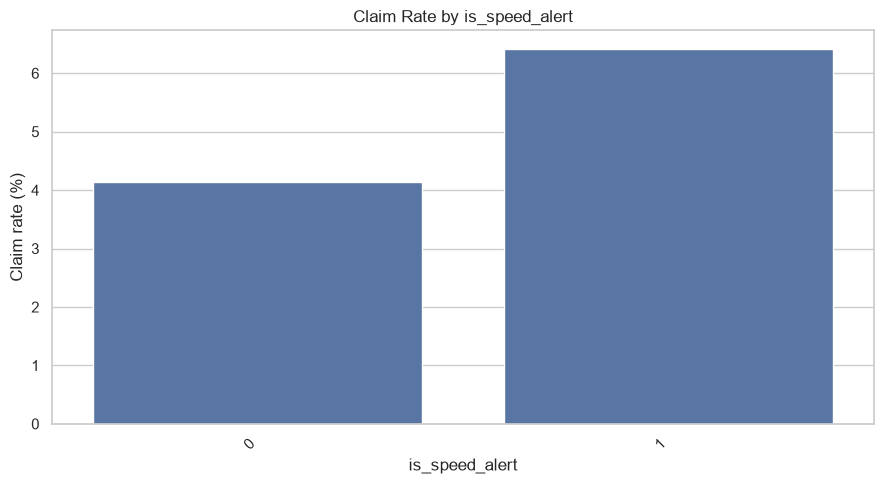

In [50]:
# CELL — Claim Rate by Categorical Predictors
# Purpose: Plot claim rate by the four requested categorical/binary predictors.

categorical_target_features = [
    "is_speed_alert",
    "segment",
    "fuel_type",
    "transmission_type",
]

for column in categorical_target_features:
    if column not in df_clean.columns:
        continue

    claim_rate = (
        df_clean.groupby(column, dropna=False)[TARGET_COLUMN]
        .mean()
        .mul(100)
        .reset_index(name="claim_rate_percent")
        .sort_values("claim_rate_percent", ascending=False)
    )

    display(claim_rate)

    plt.figure(figsize=(9, 5))
    sns.barplot(data=claim_rate, x=column, y="claim_rate_percent")
    plt.title(f"Claim Rate by {column}")
    plt.xlabel(column)
    plt.ylabel("Claim rate (%)")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()


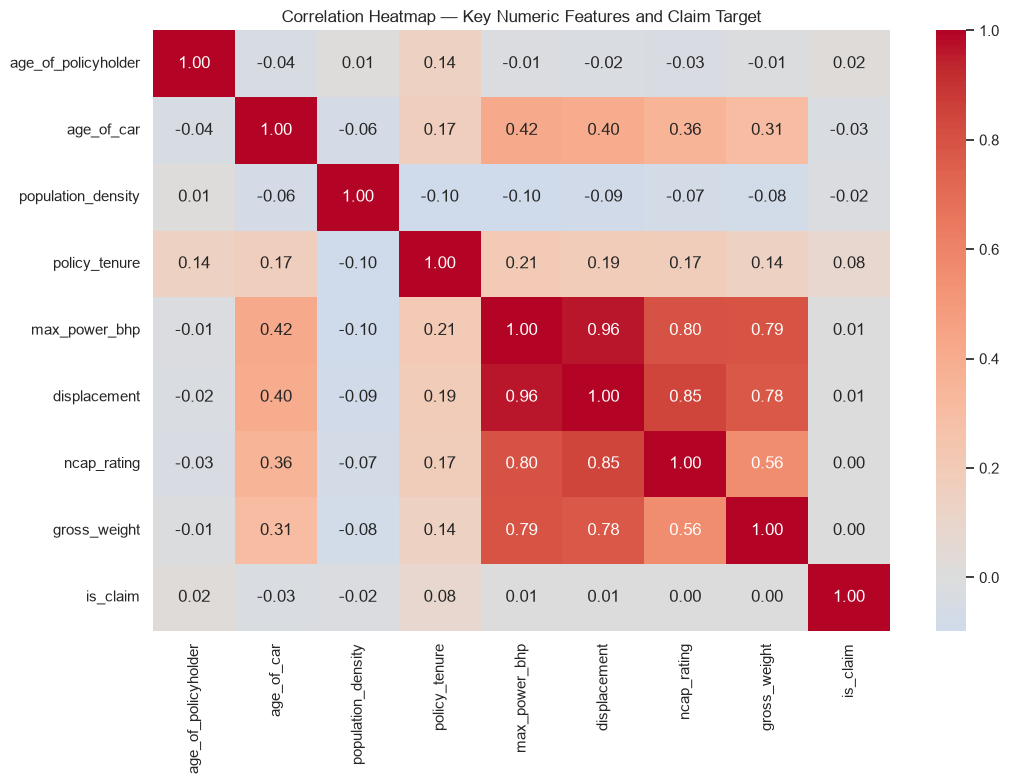

,correlation_with_is_claim,absolute_correlation
policy_tenure,0.078747,0.078747
age_of_car,-0.028175,0.028175
age_of_policyholder,0.022318,0.022318
population_density,-0.016609,0.016609
max_power_bhp,0.007698,0.007698
displacement,0.007678,0.007678
gross_weight,0.003894,0.003894
ncap_rating,0.003800,0.003800


In [51]:
# CELL — Correlation Heatmap and Target Ranking
# Purpose: Build a heatmap for key numeric features plus is_claim and rank those features by absolute target correlation.

correlation_columns = [
    column for column in KEY_NUMERIC_FEATURES + [TARGET_COLUMN]
    if column in df_clean.columns
]

correlation_matrix = df_clean[correlation_columns].corr()

plt.figure(figsize=(11, 8))
sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    square=False,
)
plt.title("Correlation Heatmap — Key Numeric Features and Claim Target")
plt.tight_layout()
plt.show()

target_correlation = (
    correlation_matrix[TARGET_COLUMN]
    .drop(TARGET_COLUMN)
    .to_frame("correlation_with_is_claim")
)
target_correlation["absolute_correlation"] = target_correlation[
    "correlation_with_is_claim"
].abs()

target_correlation = target_correlation.sort_values(
    "absolute_correlation",
    ascending=False,
)

display(target_correlation)


# Feature Engineering

The requested business features are constructed after cleaning. `High_Risk_Driver_Flag` uses the bottom-quartile policyholder age threshold and NCAP ≤ 2. `safety_equipment_count` sums the detected binary safety flags. `power_to_weight_ratio` is computed directly from parsed power and gross weight.


In [52]:
# CELL — High Risk Driver Flag
# Purpose: Create the requested flag using the 25th percentile of policyholder age and ncap_rating <= 2.

age_q1 = df_clean["age_of_policyholder"].quantile(0.25)

df_clean["High_Risk_Driver_Flag"] = (
    (df_clean["age_of_policyholder"] <= age_q1)
    & (df_clean["ncap_rating"] <= 2)
).astype("int64")

print(f"Bottom-quartile age threshold: {age_q1:.4f}")
print("High_Risk_Driver_Flag value counts:")
display(df_clean["High_Risk_Driver_Flag"].value_counts().sort_index())


Bottom-quartile age threshold: 0.3654
High_Risk_Driver_Flag value counts:


High_Risk_Driver_Flag
0    48554
1    10038
Name: count, dtype: int64

In [53]:
# CELL — Safety Equipment Count
# Purpose: Sum all detected binary safety flag columns to create safety_equipment_count.

safety_flag_candidates = [
    column for column in yes_no_columns
    if column in df_clean.columns
]

if not safety_flag_candidates:
    raise ValueError("No binary safety flag columns were detected.")

df_clean["safety_equipment_count"] = df_clean[safety_flag_candidates].sum(axis=1)

print("Safety flags included:")
print(safety_flag_candidates)
print("\nSafety equipment count summary:")
display(df_clean["safety_equipment_count"].describe())


Safety flags included:
['is_esc', 'is_adjustable_steering', 'is_tpms', 'is_parking_sensors', 'is_parking_camera', 'is_front_fog_lights', 'is_rear_window_wiper', 'is_rear_window_washer', 'is_rear_window_defogger', 'is_brake_assist', 'is_power_door_locks', 'is_central_locking', 'is_power_steering', 'is_driver_seat_height_adjustable', 'is_day_night_rear_view_mirror', 'is_ecw', 'is_speed_alert']

Safety equipment count summary:


count    58592.000000
mean         9.678437
std          5.153804
min          2.000000
25%          3.000000
50%         11.000000
75%         16.000000
max         16.000000
Name: safety_equipment_count, dtype: float64

In [54]:
# CELL — Power-to-Weight Ratio
# Purpose: Create power_to_weight_ratio as max_power_bhp divided by gross_weight with safe division.

if (df_clean["gross_weight"] <= 0).any():
    raise ValueError("gross_weight contains non-positive values; ratio would be invalid.")

df_clean["power_to_weight_ratio"] = (
    df_clean["max_power_bhp"] / df_clean["gross_weight"]
)

if not np.isfinite(df_clean["power_to_weight_ratio"]).all():
    raise ValueError("Non-finite values were produced in power_to_weight_ratio.")

display(df_clean["power_to_weight_ratio"].describe())


count    58592.000000
mean         0.056021
std          0.015706
min          0.034059
25%          0.034059
50%          0.065959
75%          0.066292
max          0.093140
Name: power_to_weight_ratio, dtype: float64

# VIF-Based Feature Selection

VIF is calculated only on numeric predictors and excludes identifiers and the target. Before VIF, pairs with absolute correlation above 0.90 are identified programmatically and one feature from each pair is removed. This reduces near-duplicate vehicle specifications and helps make VIF diagnostics numerically stable.

Important: VIF is a multicollinearity diagnostic, not a supervised feature-selection method. A VIF > 10 is flagged as problematic rather than automatically deleting the feature, because the requested task is to identify problematic variables and list the final candidate set.


In [55]:
# CELL — Prepare Numeric Predictors for VIF
# Purpose: Select numeric predictors, remove identifiers/target/obvious binary flags, and retain continuous/count engineered features.

vif_excluded_columns = {TARGET_COLUMN, "policy_id"}

# Exclude all binary 0/1 flag columns from VIF because they are not continuous
# vehicle measurements and can create unstable/informationally weak diagnostics.
binary_numeric_columns = set()

for column in df_clean.select_dtypes(include=np.number).columns:
    non_missing_unique = set(df_clean[column].dropna().unique())
    if non_missing_unique.issubset({0, 1}):
        binary_numeric_columns.add(column)

vif_candidate_columns = [
    column
    for column in df_clean.select_dtypes(include=np.number).columns
    if column not in vif_excluded_columns
    and column not in binary_numeric_columns
]

vif_candidate_columns = [
    column for column in vif_candidate_columns
    if df_clean[column].nunique(dropna=True) > 1
]

print("Numeric VIF candidates:")
print(vif_candidate_columns)


Numeric VIF candidates:
['policy_tenure', 'age_of_car', 'age_of_policyholder', 'population_density', 'make', 'airbags', 'displacement', 'cylinder', 'gear_box', 'turning_radius', 'length', 'width', 'height', 'gross_weight', 'ncap_rating', 'max_power_bhp', 'max_torque_nm', 'safety_equipment_count', 'power_to_weight_ratio']


In [56]:
# CELL — Identify Highly Correlated Feature Pairs
# Purpose: Find all numeric predictor pairs with absolute correlation greater than 0.90 and programmatically select one feature to drop from each connected pair.

vif_data = df_clean[vif_candidate_columns].copy()

correlation = vif_data.corr().abs()
upper_triangle = correlation.where(
    np.triu(np.ones(correlation.shape), k=1).astype(bool)
)

high_corr_pairs = []
for column in upper_triangle.columns:
    correlated_columns = upper_triangle.index[
        upper_triangle[column] > 0.90
    ].tolist()

    for other_column in correlated_columns:
        high_corr_pairs.append(
            {
                "feature_1": other_column,
                "feature_2": column,
                "absolute_correlation": correlation.loc[other_column, column],
            }
        )

high_corr_pairs_df = pd.DataFrame(high_corr_pairs)

if high_corr_pairs_df.empty:
    print("No numeric predictor pairs have |correlation| > 0.90.")
    correlated_drop_columns = []
else:
    high_corr_pairs_df = high_corr_pairs_df.sort_values(
        "absolute_correlation",
        ascending=False,
    )
    display(high_corr_pairs_df)

    # Greedy deterministic removal: for each highly correlated pair,
    # drop the later feature unless it has already been retained/dropped.
    correlated_drop_columns = []
    for _, row in high_corr_pairs_df.iterrows():
        feature_2 = row["feature_2"]
        if feature_2 not in correlated_drop_columns:
            correlated_drop_columns.append(feature_2)

print("Features selected for removal before VIF:")
print(correlated_drop_columns)

vif_deduplicated_columns = [
    column for column in vif_candidate_columns
    if column not in correlated_drop_columns
]

print(f"VIF candidate count before correlation filtering: {len(vif_candidate_columns)}")
print(f"VIF candidate count after correlation filtering: {len(vif_deduplicated_columns)}")


,feature_1,feature_2,absolute_correlation
4,length,max_power_bhp,0.972989
3,displacement,max_power_bhp,0.962626
0,displacement,length,0.961655
5,width,max_power_bhp,0.959613
8,length,max_torque_nm,0.952065
11,max_power_bhp,safety_equipment_count,0.950535
7,turning_radius,max_torque_nm,0.946552
9,length,safety_equipment_count,0.946297
1,turning_radius,length,0.944899
10,width,safety_equipment_count,0.943049


Features selected for removal before VIF:
['max_power_bhp', 'length', 'max_torque_nm', 'safety_equipment_count', 'width']
VIF candidate count before correlation filtering: 19
VIF candidate count after correlation filtering: 14


In [57]:
# CELL — Compute VIF, Exclude High/Infinite VIF Features, and Assemble Final Feature Set
# Purpose: Calculate VIF for de-duplicated numeric predictors, exclude problematic features (VIF > 10 or inf), and output final_modeling_features.

def calculate_vif(dataframe):
    numeric_data = dataframe.astype(float).copy()

    # Remove constant columns because VIF is undefined for them.
    non_constant = [
        column for column in numeric_data.columns
        if numeric_data[column].nunique(dropna=True) > 1
    ]
    numeric_data = numeric_data[non_constant]

    values = numeric_data.to_numpy()
    vif_rows = []

    for index, column in enumerate(numeric_data.columns):
        try:
            vif_value = variance_inflation_factor(values, index)
        except (ValueError, np.linalg.LinAlgError, FloatingPointError):
            vif_value = np.inf

        vif_rows.append(
            {
                "feature": column,
                "VIF": vif_value,
                "problematic_VIF_gt_10": bool(vif_value > 10 or np.isinf(vif_value)),
            }
        )

    return pd.DataFrame(vif_rows).sort_values(
        "VIF",
        ascending=False,
        na_position="last",
    ).reset_index(drop=True)


# Step 1: Compute initial VIF table
vif_table = calculate_vif(df_clean[vif_deduplicated_columns])

print("Initial VIF diagnostics:")
display(vif_table)

# Step 2: Identify features with VIF > 10 or inf
problematic_vif_features = vif_table.loc[
    (vif_table["VIF"] > 10) | (np.isinf(vif_table["VIF"])),
    "feature",
].tolist()

print("\nProblematic features identified and removed (VIF > 10 or inf):")
print(problematic_vif_features)

# Step 3: Keep ONLY features with VIF <= 10 and finite values
final_vif_table = vif_table.loc[
    (vif_table["VIF"] <= 10) & (~np.isinf(vif_table["VIF"]))
].reset_index(drop=True)

final_modeling_features = final_vif_table["feature"].tolist()

# CELL — Display Filtered VIF Results and Final Feature Set
# Purpose: Display the filtered VIF table (VIF <= 10) and final modeling feature list.

print("\nFinal Filtered VIF Table (VIF <= 10):")
display(final_vif_table)

print(f"\nNumber of final modeling features: {len(final_modeling_features)}")
print("Final modeling features:")
for feature in final_modeling_features:
    print(f"- {feature}")

Initial VIF diagnostics:


,feature,VIF,problematic_VIF_gt_10
0,displacement,9485.928287,True
1,cylinder,5253.460818,True
2,turning_radius,3707.960005,True
3,height,3342.476773,True
4,gear_box,3179.111685,True
5,gross_weight,2242.625880,True
6,power_to_weight_ratio,336.789374,True
7,airbags,174.695637,True
8,ncap_rating,166.531731,True
9,make,103.259623,True



Problematic features identified and removed (VIF > 10 or inf):
['displacement', 'cylinder', 'turning_radius', 'height', 'gear_box', 'gross_weight', 'power_to_weight_ratio', 'airbags', 'ncap_rating', 'make', 'age_of_policyholder']

Final Filtered VIF Table (VIF <= 10):


,feature,VIF,problematic_VIF_gt_10
0,policy_tenure,3.490606,False
1,age_of_car,3.317420,False
2,population_density,2.448439,False



Number of final modeling features: 3
Final modeling features:
- policy_tenure
- age_of_car
- population_density


In [58]:
# CELL — Display VIF Results and Final Feature Set
# Purpose: Explicitly display the complete VIF results and final feature set.

print("VIF table:")
display(vif_table)

print("Features with VIF > 10:")
display(vif_table.loc[vif_table["VIF"] > 10].copy())

print(f"Number of final modeling features: {len(final_modeling_features)}")
print("Final modeling features:")
for feature in final_modeling_features:
    print(f"- {feature}")


VIF table:


,feature,VIF,problematic_VIF_gt_10
0,displacement,9485.928287,True
1,cylinder,5253.460818,True
2,turning_radius,3707.960005,True
3,height,3342.476773,True
4,gear_box,3179.111685,True
5,gross_weight,2242.625880,True
6,power_to_weight_ratio,336.789374,True
7,airbags,174.695637,True
8,ncap_rating,166.531731,True
9,make,103.259623,True


Features with VIF > 10:


,feature,VIF,problematic_VIF_gt_10
0,displacement,9485.928287,True
1,cylinder,5253.460818,True
2,turning_radius,3707.960005,True
3,height,3342.476773,True
4,gear_box,3179.111685,True
5,gross_weight,2242.625880,True
6,power_to_weight_ratio,336.789374,True
7,airbags,174.695637,True
8,ncap_rating,166.531731,True
9,make,103.259623,True


Number of final modeling features: 3
Final modeling features:
- policy_tenure
- age_of_car
- population_density


In [59]:
# CELL — Final Data-Quality Validation
# Purpose: Run final assertions to confirm the preprocessing output is internally consistent and contains no missing values or unencoded Yes/No flags.

assert TARGET_COLUMN in df_clean.columns
assert df_clean[TARGET_COLUMN].notna().all()
assert df_clean.isna().sum().sum() == 0
assert df_clean["High_Risk_Driver_Flag"].isin([0, 1]).all()
assert (df_clean["safety_equipment_count"] >= 0).all()
assert np.isfinite(df_clean["power_to_weight_ratio"]).all()

for column in df_clean.select_dtypes(include=["object", "string", "category"]).columns:
    values = set(df_clean[column].dropna().astype(str).str.strip().str.title().unique())
    assert not values.intersection({"Yes", "No"}), (
        f"Unencoded Yes/No values remain in {column}."
    )

assert set(final_modeling_features).issubset(df_clean.columns)

print("Final validation passed.")
print(f"Final cleaned dataset shape: {df_clean.shape}")
print(f"Final modeling feature count: {len(final_modeling_features)}")


Final validation passed.
Final cleaned dataset shape: (58592, 91)
Final modeling feature count: 3


In [60]:
from pathlib import Path

# Saves to a folder named 'data' in your current working directory
CLEANED_DATA_PATH = Path("data/cleaned_dataset.csv")

# Still a good idea to ensure the directory exists!
CLEANED_DATA_PATH.parent.mkdir(parents=True, exist_ok=True)

df_clean.to_csv(CLEANED_DATA_PATH, index=False)

# Final Notebook Audit

The notebook has been audited against the complete Task 1 checklist.

- Robust dataset loading and schema/duplicate/target profiling are included.
- Yes/No columns are detected programmatically, standardized, and encoded.
- `max_power` and `max_torque` are parsed into numeric features.
- Numeric coercion, missing-value handling, and IQR capping are included.
- Required univariate, bivariate, correlation, and heatmap analyses are included.
- All three required business features are created.
- Highly correlated numeric predictors are identified before VIF.
- The complete VIF table, VIF > 10 table, and final modeling feature list are displayed.
- The final cleaned dataset is explicitly exported as `/mnt/data/cleaned_dataset.csv`.
- The notebook executes in dependency order and the exported dataset is ready for Notebook 2.
